In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ROOT
mpl.rc('text', usetex = True)

In [2]:
# Only limited to spin-1 so can have it be a bit hardcodey
# Changing from root branch name to wave format
# i.e. a_T_1_0 = P^+_{T0}
def ToWave(phase):
    tmp = phase.split('_')
    refl = "+"
    pol = tmp[1]
    wave = "S"
    m = "0"

    if tmp[0] == 'b':
        refl = "-"

    if tmp[2] == '1':
        wave = "P"
    elif tmp[2] == '2':
        wave = "D"

    if tmp[3][0] == 'm':
        m = "-"+tmp[3][1]
    else:
        m = tmp[3][0]

    return wave + "$^" + refl + "_{\\mathrm{" + pol + "}" + m + "}$"

In [3]:
def circular_mean(phi):
    return np.angle(np.mean(np.exp(1j * phi)))

def circular_std(phi):
    R = np.abs(np.mean(np.exp(1j * phi)))
    return np.sqrt(-2 * np.log(R))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35


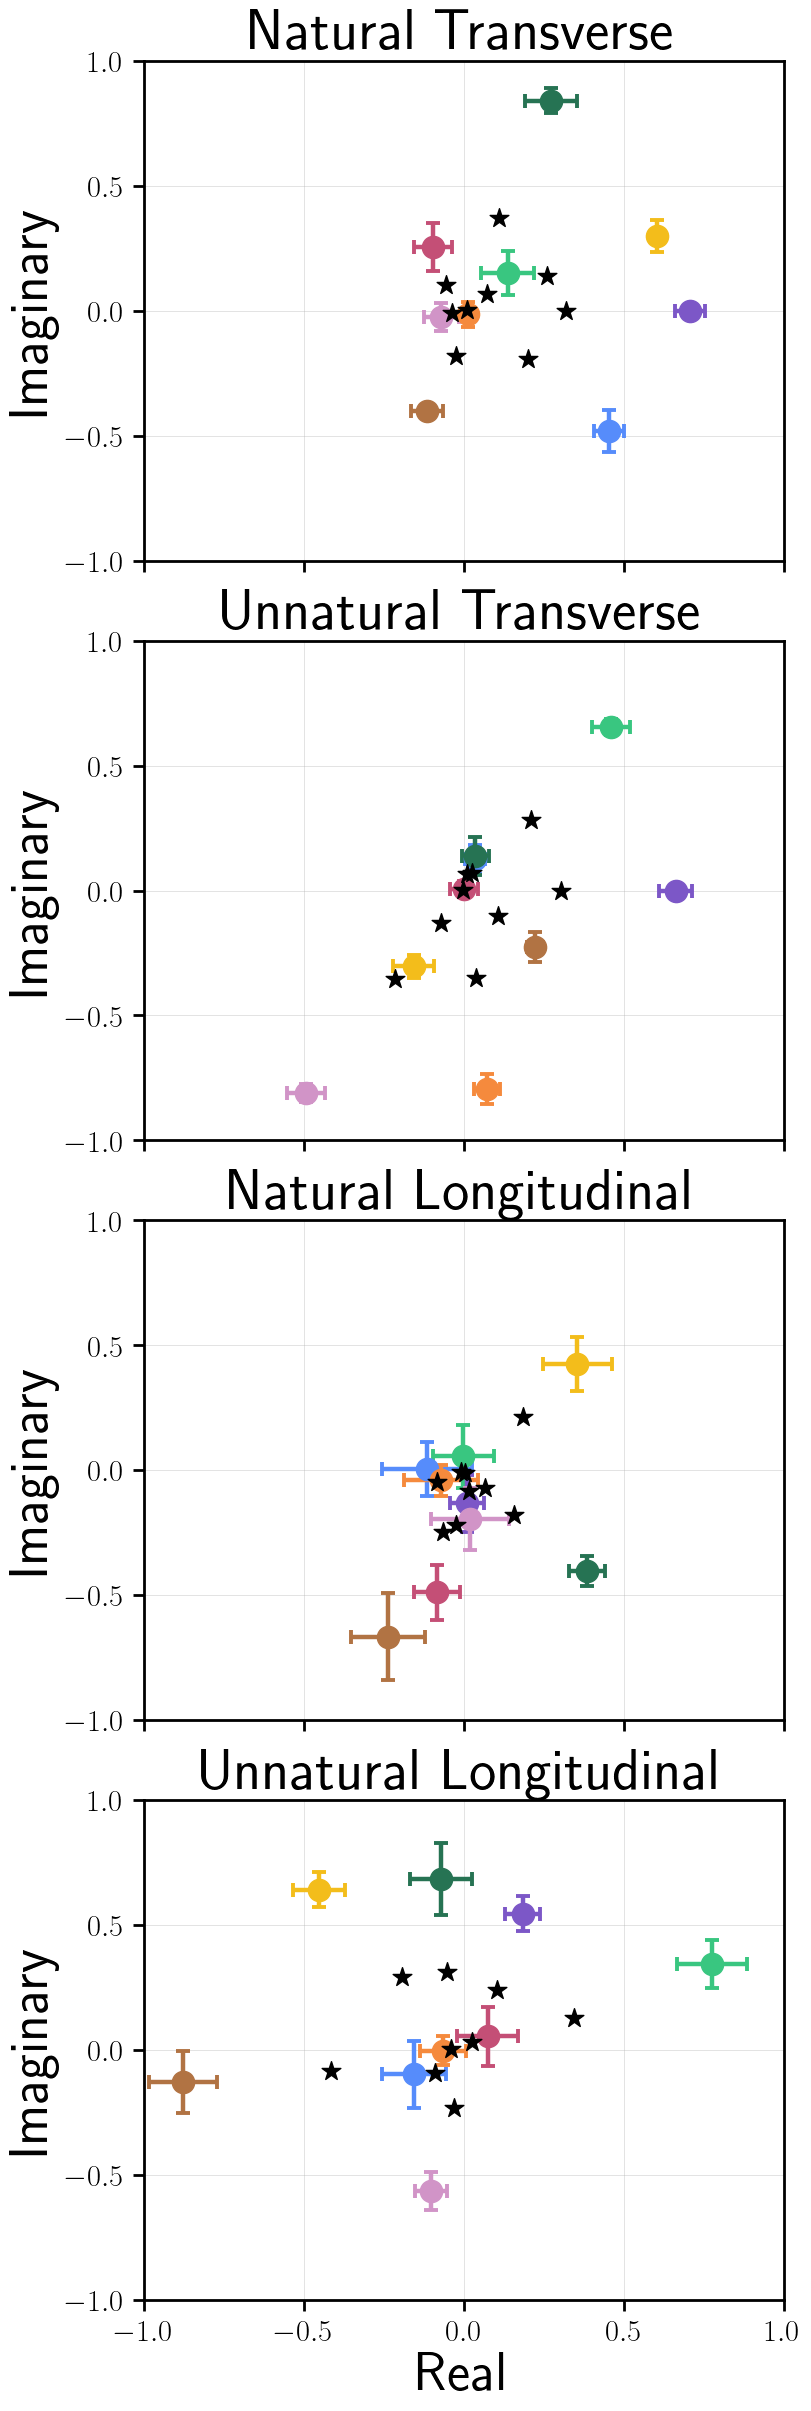

In [4]:
plt.rcParams.update({
    "font.size": 36,
    "axes.titlesize": 42,
    "axes.labelsize": 40,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 34,
    "lines.linewidth": 4.0,
    "axes.linewidth": 2.8,
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,
    "xtick.minor.size": 6,
    "ytick.minor.size": 6,
})

def apply_poster_axis_style(ax, labelsize=20):
    ax.tick_params(axis='both', which='major', labelsize=labelsize, width=2.0, length=8, pad=6)
    ax.tick_params(axis='both', which='minor', width=1.6, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
# Initialise arrays for each wave
aT = np.empty(4)
bT = np.empty(4)
aL = np.empty(4)
bL = np.empty(4)

# DataFrame column names
cols_mag = [
    "a_T_0_0", "a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_2_2", "a_T_2_1", "a_T_2_0", "a_T_2_m1", "a_T_2_m2",
    "b_T_0_0","b_T_1_1", "b_T_1_0", "b_T_1_m1", "b_T_2_2", "b_T_2_1", "b_T_2_0", "b_T_2_m1", "b_T_2_m2",
    "a_L_0_0", "a_L_1_1", "a_L_1_0", "a_L_1_m1", "a_L_2_2", "a_L_2_1", "a_L_2_0", "a_L_2_m1", "a_L_2_m2",
    "b_L_0_0","b_L_1_1", "b_L_1_0", "b_L_1_m1", "b_L_2_2", "b_L_2_1", "b_L_2_0", "b_L_2_m1", "b_L_2_m2"
]

cols_phase = [
    "aphi_T_0_0", "aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1", "aphi_T_2_2", "aphi_T_2_1", "aphi_T_2_0", "aphi_T_2_m1", "aphi_T_2_m2",
    "bphi_T_0_0","bphi_T_1_1", "bphi_T_1_0", "bphi_T_1_m1", "bphi_T_2_2", "bphi_T_2_1", "bphi_T_2_0", "bphi_T_2_m1", "bphi_T_2_m2",
    "aphi_L_0_0", "aphi_L_1_1", "aphi_L_1_0", "aphi_L_1_m1", "aphi_L_2_2", "aphi_L_2_1", "aphi_L_2_0", "aphi_L_2_m1", "aphi_L_2_m2",
    "bphi_L_0_0","bphi_L_1_1", "bphi_L_1_0", "bphi_L_1_m1", "bphi_L_2_2", "bphi_L_2_1", "bphi_L_2_0", "bphi_L_2_m1", "bphi_L_2_m2"
]

tru_mags = np.array([
    # a_T
    0.278093, 0.010878, 0.119613, 0.097077,
    0.320298, 0.294303, 0.388018, 0.037811, 0.183498,

    # b_T
    0.073704, 0.352029, 0.002826, 0.350459,
    0.303627, 0.147978, 0.067619, 0.416301, 0.146388,

    # a_L
    0.012959, 0.095088, 0.219784, 0.011541,
    0.086477, 0.282641, 0.237000, 0.095872, 0.256278,

    # b_L
    0.129168, 0.040336, 0.042063, 0.368583,
    0.262566, 0.351028, 0.317368, 0.233211, 0.423218,
], dtype=float)

#tru_mags = (tru_mags*np.sqrt(1/np.sum(np.square(tru_mags))))

tru_phases = np.array([
    # aphi_T
    -0.763191,  0.326981,  2.069711,  0.744682,
     0.000000,  0.486018,  1.285363, -2.853670, -1.709666,

    # bphi_T
     1.223400, -1.464122,  2.743582,  0.930134,
     0.000000, -2.066297,  1.439646, -2.114905, -0.757404,

    # aphi_L
    -1.323314, -2.640245, -1.678924, -2.506982,
    -1.395033,  0.852531, -0.849284, -0.815677, -1.825221,

    # bphi_L
    -2.334500,  3.075766,  0.879644,  0.357826,
     1.159966,  2.154202,  1.734159, -1.702441, -2.939901,
], dtype=float)

Q2 = np.array([1])

titles = ["Natural Transverse", "Unnatural Transverse" , "Natural Longitudinal", "Unnatural Longitudinal"]
legends = ["$(1,1)$", "$(1,0)$", "$(1,-1)$", "$(0,0)$"]
N  = 903
# For HERMEs data they are saved this way (4 Q2 bins)
df = ROOT.RDataFrame("fitResults", "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/fixed-amp-test.root")
df = df.Filter("log_val<=3")
arrays_mag = df.AsNumpy(columns=cols_mag)
arrays_phase = df.AsNumpy(columns=cols_phase)

fig, axs = plt.subplots(4, 1, figsize=(8, 24), sharex=True, constrained_layout=True)
for j in range(4):
    #The main plotting
    for k in range(9):
        print(k + 9*j)
        mag = arrays_mag[cols_mag[k + 9*j]]
        phase = arrays_phase[cols_phase[k + 9*j]]

        tru_mag = tru_mags[k + 9*j]
        tru_phase = tru_phases[k + 9*j]

        re = mag*np.cos(phase)
        im = mag*np.sin(phase)

        tru_re = tru_mag*np.cos(tru_phase)
        tru_im = tru_mag*np.sin(tru_phase)

        mean_mag = np.mean(mag)
        err_mag = np.std(mag)

        mean_phase = circular_mean(phase)
        # if (cols_mag[k + 9*j] == "a_L_1_0" or k==3):
        #     mean_phase = 0
        err_phase= circular_std(phase)

        mean_re = np.mean(re)
        err_re= np.std(re)

        mean_im = np.mean(im)
        err_im = np.std(im)

        # axs[j,0].errorbar(mean_phase,mean_mag,xerr = err_phase,yerr = err_mag, fmt='.', markersize=14, elinewidth=2)
        # axs[j,0].axis(xmin=-np.pi, xmax = np.pi, ymin = -0.05, ymax = 1)
        # axs[j,0].scatter(tru_phase, tru_mag, zorder=5, marker="*", color="black")

        if j==0:
            axs[j].errorbar(mean_re,mean_im,xerr = err_re,yerr = err_im,fmt='o', markersize=16, elinewidth=3.2,
                   capsize=5, capthick=2.8,
                   label=ToWave(cols_mag[k + 9*j])
               )
            if k==3:
                axs[j].scatter(tru_re, tru_im, zorder=5, marker="*", color="black", s=200, label="Set Amp")
            else:
                axs[j].scatter(tru_re, tru_im, zorder=5, marker="*", s=200, color="black")
        else:
            axs[j].errorbar(mean_re,mean_im,xerr = err_re,yerr = err_im,fmt='o', markersize=16, elinewidth=3.2,
                    capsize=5, capthick=2.8,
                    label=ToWave(cols_mag[k + 9*j])
                )
            axs[j].scatter(tru_re, tru_im, zorder=5, marker="*", s=200, color="black")
        axs[j].axis(xmin=-1, xmax = 1, ymin = -1, ymax = 1)

        # axs[j,0].set_ylabel("Magnitude")
        axs[j].set_ylabel("Imaginary")
        if (j==3):
            # axs[j,0].set_xlabel("Phase")
            axs[j].set_xlabel("Real")

        axs[j].set_title(titles[j])
        axs[j].set_yticks([-1,-0.5,0,0.5,1])
        axs[j].set_xticks([-1,-0.5,0,0.5,1])
        axs[j].grid(True, alpha=0.5)
        #axs[j].legend(loc="upper left", frameon=False, fontsize=20)
        apply_poster_axis_style(axs[j], labelsize=22)



    # Maybe have an overall title giving more information?
    #fig.tight_layout()
    fig.savefig("fixed_amps_zoom.pdf", dpi=600,bbox_inches='tight',transparent=True, format= 'pdf')

0.08115980788605769


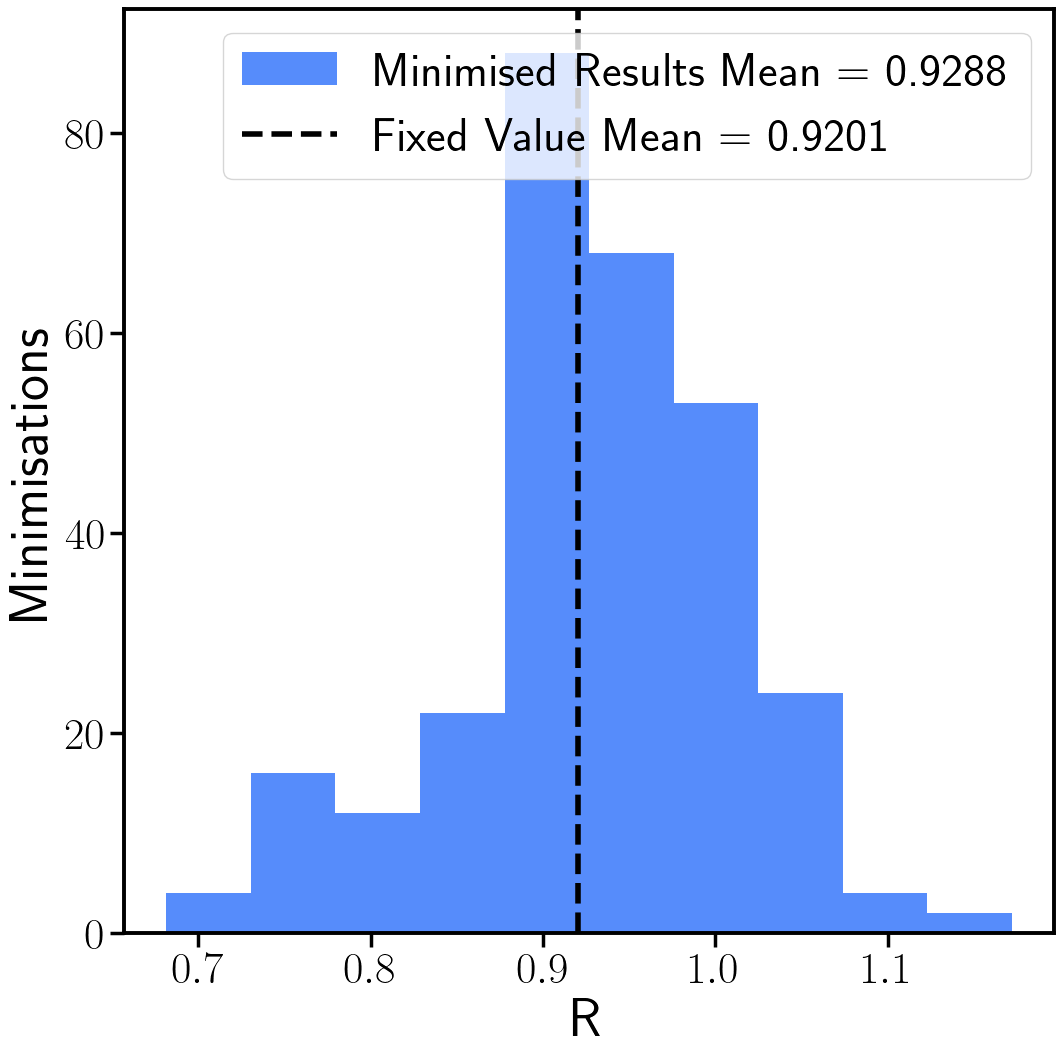

In [5]:
R_legit = 10.13361794/11.01401655

%jsroot on

df = ROOT.RDataFrame("fitResults", "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/fixed-amp-test.root")
df = df.Filter("log_val<=3.5")

moments = df.AsNumpy(columns=["H_0_0_0","H_4_0_0"])

R = moments["H_4_0_0"]/moments["H_0_0_0"]
print(R.std())
plt.figure(figsize=(12,12))
plt.hist(R, label="Minimised Results Mean = "+str(round(float(R.mean()),4)))
plt.xlabel("R")
plt.ylabel("Minimisations")
plt.axvline(x=R_legit, linestyle="--", color="black", label="Fixed Value Mean = "+str(round(R_legit,4)))
plt.legend()
plt.savefig("R_hist.png")
